# 08/05/25

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

visa_df=pd.read_csv('Visadataset.csv')
visa_df

cat_cols=visa_df.select_dtypes(include='object').columns
num_cols=visa_df.select_dtypes(exclude='object').columns
num_cols,cat_cols

(Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object'),
 Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
        'requires_job_training', 'region_of_employment', 'unit_of_wage',
        'full_time_position', 'case_status'],
       dtype='object'))

- Generally data has 3 types

    - Postive skew

    - Negtaive skew

    - No skew

- Skew ness happend becuase of Outliers

- eventhough we treat the outliers still we can see some skew

- And we know that all the math developed by make an assumption as **Data follows Normal distribution**
    
- so transformation methods used to convert data to Normal
    
- The important Transformations are
    
    - Log Transformation
    
    - Reciprocal Transformation
    
    - Sqrt Transformation
    
    - Exponential Transformation
    
    - Power Transformation

$Step-1$

In [71]:
import numpy as np
import matplotlib.pyplot as plt

$Step-2$: **read exponential data**

In [74]:
exp_data=np.random.exponential(size=10000)
exp_data

array([2.11314221, 3.88223781, 1.13898479, ..., 0.03736989, 0.4766152 ,
       0.27411196])

$Step-3$: **plot histogram**

(array([5.93e+03, 2.43e+03, 9.89e+02, 3.92e+02, 1.56e+02, 6.30e+01,
        2.60e+01, 7.00e+00, 6.00e+00, 1.00e+00]),
 array([3.62435155e-06, 9.13779148e-01, 1.82755467e+00, 2.74133019e+00,
        3.65510572e+00, 4.56888124e+00, 5.48265677e+00, 6.39643229e+00,
        7.31020781e+00, 8.22398334e+00, 9.13775886e+00]),
 <BarContainer object of 10 artists>)

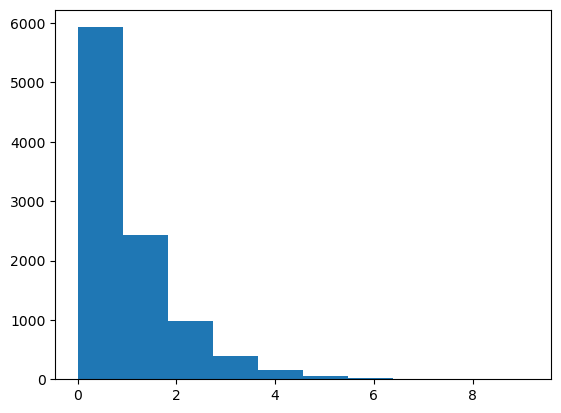

In [77]:
plt.hist(exp_data)

<Axes: ylabel='Density'>

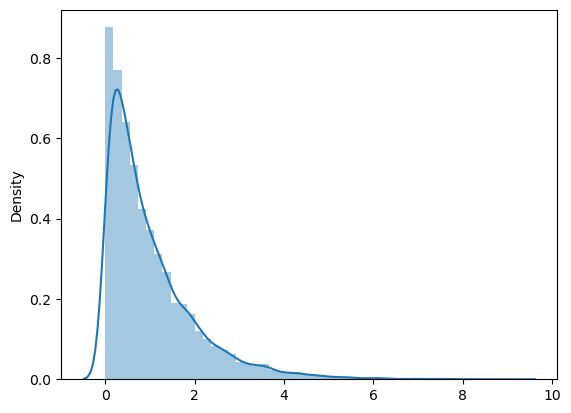

In [79]:
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.distplot(exp_data)

In [81]:
normal_data=np.random.normal(size=100000)
normal_data

array([ 0.26367757,  0.18254413, -0.26302474, ..., -0.21881357,
        0.34891071, -2.13707522])

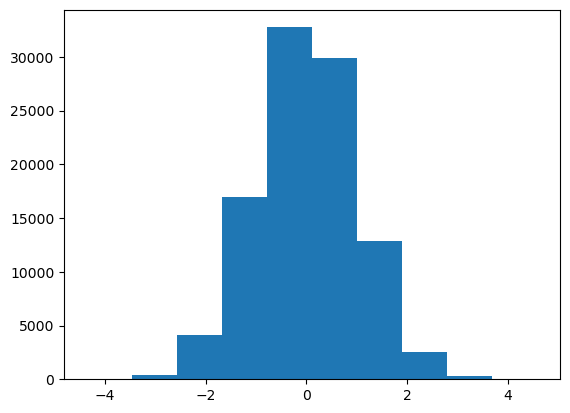

In [83]:
plt.hist(normal_data)
plt.show()

**Goal**

- Convert Exponential data to Normal data

**Log Transformation**

- Log transformation means performing logarithm operations on original data

- It is one of the approach to convert data to Normality

- Log means natural logarithm base=e

In [87]:
x=2
np.log(x)

0.6931471805599453

In [89]:
log_data=np.log(exp_data)
log_data

array([ 0.74817604,  1.35641174,  0.13013733, ..., -3.28689002,
       -0.74104582, -1.29421864])

In [ ]:
# we are hoping log data might follows normality
# it might be possible or might not be possible
# we need to plot histogram again on log data

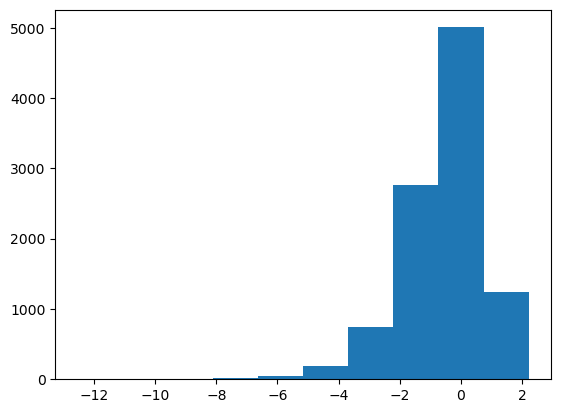

In [91]:
plt.hist(log_data)
plt.show()

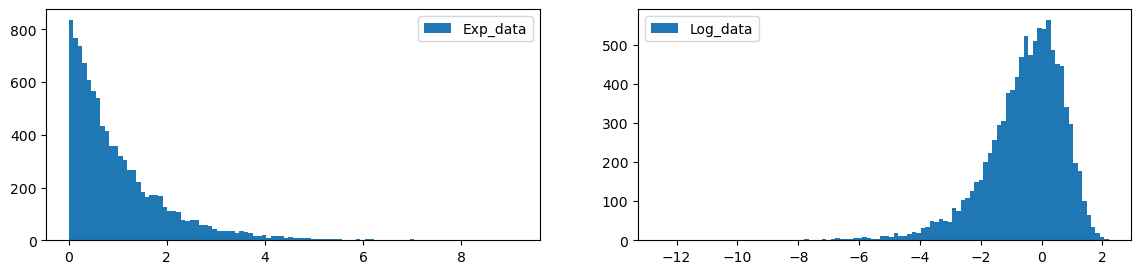

In [93]:
plt.figure(figsize=(14,3))
plt.subplot(1,2,1).hist(exp_data,bins=100,label='Exp_data')
plt.legend()
plt.subplot(1,2,2).hist(log_data,bins=100,label='Log_data')
plt.legend()
plt.show()

**Square root Transformation: np.sqrt**

In [96]:
sqrt_data=np.sqrt(exp_data)
sqrt_data

array([1.4536651 , 1.97033952, 1.0672323 , ..., 0.19331293, 0.69037323,
       0.52355703])

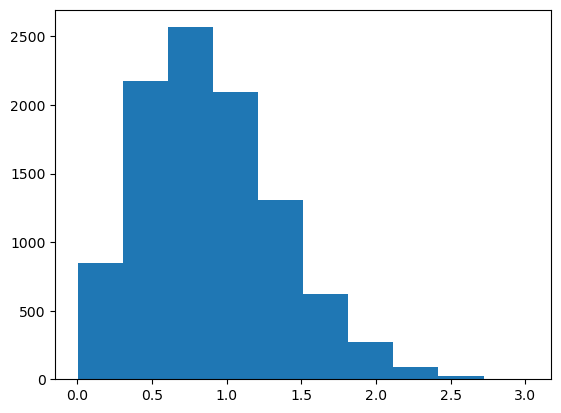

In [98]:
plt.hist(sqrt_data)
plt.show()

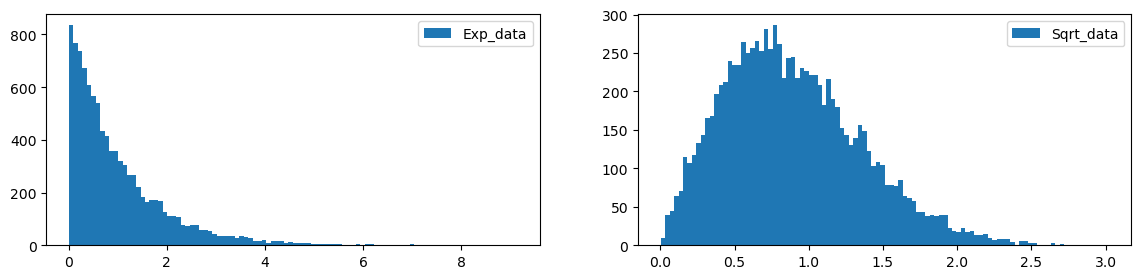

In [100]:
plt.figure(figsize=(14,3))
plt.subplot(1,2,1).hist(exp_data,bins=100,label='Exp_data')
plt.legend()
plt.subplot(1,2,2).hist(sqrt_data,bins=100,label='Sqrt_data')
plt.legend()
plt.show()

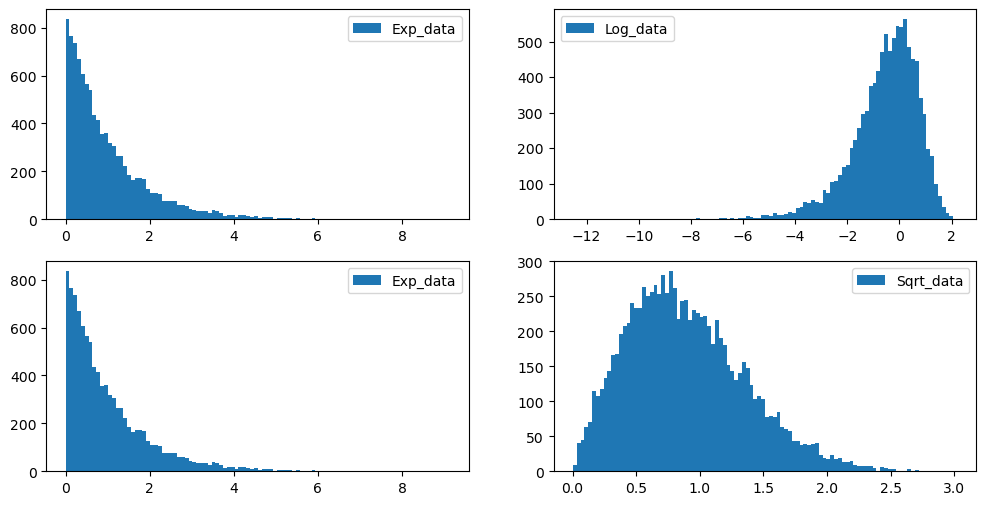

In [101]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1).hist(exp_data,bins=100,label='Exp_data')
plt.legend()
plt.subplot(2,2,2).hist(log_data,bins=100,label='Log_data')
plt.legend()
plt.subplot(2,2,3).hist(exp_data,bins=100,label='Exp_data')
plt.legend()
plt.subplot(2,2,4).hist(sqrt_data,bins=100,label='Sqrt_data')
plt.legend()
plt.show()

**Power Transformation**

- Power Transformation is used to Reduce the skewnes , so that distribution become symmetric

- Under these two types are there

    - Box-cox Transformation

    - It applies to only postive data

    - It has both Log transformation and square root transformation

<img src="https://miro.medium.com/v2/resize:fit:1400/1*rUojVu1FrHjxHgsTBKM2Og.png" jsaction="" class="sFlh5c FyHeAf iPVvYb" style="max-width: 884px; width: 304px; height: 145px; margin: 0px;" alt="Understanding the Box-Cox Power Transformer | by Noor Fatima | Medium" jsname="kn3ccd">

- lambda =1 : No Transformation

- lambda = 0 : Log Transformation

- lambda =0.5 : Square root transformation

**Your job is know about another method**
    
Yeo-Johnson ===== formaule tricky confused tomorrow i will ask you

- Power transformations are under sklearn package

- sklearn

    - preprocessing

        - PowerTransformation

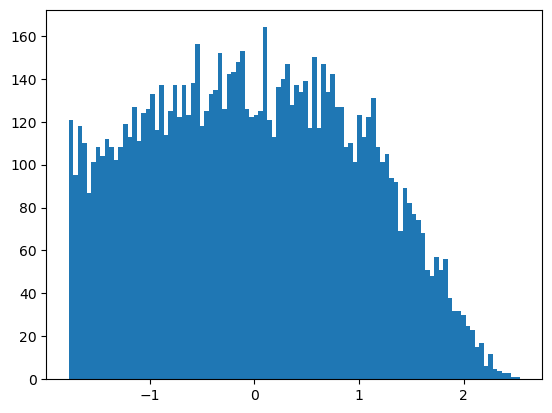

In [109]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='yeo-johnson')
exp_data=exp_data.reshape(-1,1)
trans_exp=pt.fit_transform(exp_data)
plt.hist(trans_exp,bins=100)
plt.show()

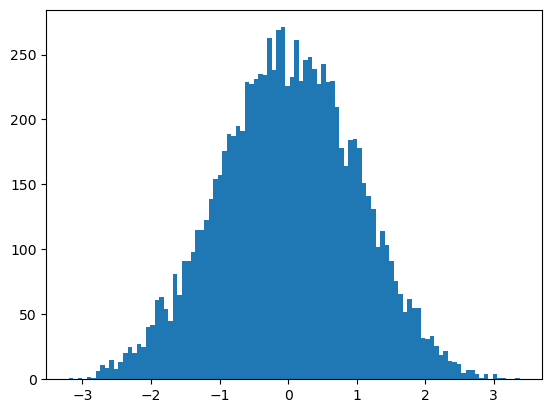

In [111]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='box-cox')
exp_data=exp_data.reshape(-1,1)
trans_exp=pt.fit_transform(exp_data)
plt.hist(trans_exp,bins=100)
plt.show()

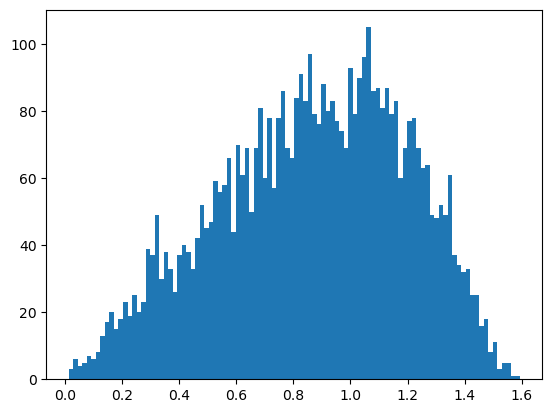

In [113]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='yeo-johnson')
exp_data=exp_data.reshape(-1,1)
trans_exp=pt.fit_transform(exp_data)
trans_sqrt=np.sqrt(trans_exp)
plt.hist(trans_sqrt,bins=100)
plt.show()